In [1]:
import os
import sys
sys.path.append('../models_en')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from DataFetcher import DataFetcher
from MUZEstimator import MUZEstimator

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = ['Arial Unicode MS']
sns.set_palette("husl")

# RiceQuant API license from env: export RQDATAC_LICENSE='your_license_key'
license = os.environ.get('RQDATAC_LICENSE')

print("="*60)
print("MUZ Volatility Estimator - CSI 300 Index")
print("="*60)


MUZ Volatility Estimator - CSI 300 Index


# 1. Initialize Data Fetcher and MUZ Estimator

We use custom classes to:
- Fetch high-frequency tick data for CSI 300 index
- Apply MUZ model to compute daily instantaneous variance proxy

In [2]:
data_fetcher = DataFetcher(license=license)
data_fetcher.init_connection()

muz_estimator = MUZEstimator(data_fetcher=data_fetcher)

RiceQuant connection established.


# 2. Test Single-Day Data Processing

Test tick size optimization on one day of data

In [3]:
test_date = '20250103'
symbol = '000300.XSHG'

df_test = data_fetcher.get_tick_data(symbol, test_date)
print(f"\nTest date: {test_date}")
print(f"Data points: {len(df_test)}")
print(f"\nPrice stats:")
print(df_test['last'].describe())


Test date: 20250103
Data points: 1200

Price stats:
count    1200.000000
mean     3817.926271
std         8.672161
min      3798.789000
25%      3812.545125
50%      3816.865550
75%      3824.944800
max      3835.935300
Name: last, dtype: float64


In [4]:
prices_test = df_test['last']

rv_uz_test, info_test = muz_estimator.calculate_rv_uz(
    prices_test, 
    optimize_tick=True, 
    verbose=True
)

print(f"\nFinal result:")
print(f"  RV^UZ = {rv_uz_test:.8f}")
print(f"  Annualized vol ≈ {np.sqrt(rv_uz_test * 252) * 100:.2f}%")


=== Tick Size Optimization ===
Target eta: 0.5

Candidates:
  tick=0.005000: eta=0.5366, N_alt=573, N_cont=615, distance=0.0366
  tick=0.006000: eta=0.5422, N_alt=569, N_cont=617, distance=0.0422
  tick=0.007000: eta=0.5441, N_alt=567, N_cont=617, distance=0.0441
  tick=0.008000: eta=0.5469, N_alt=565, N_cont=618, distance=0.0469
  tick=0.009000: eta=0.5480, N_alt=563, N_cont=617, distance=0.0480
  tick=0.010000: eta=0.5444, N_alt=563, N_cont=613, distance=0.0444
  tick=0.015000: eta=0.5565, N_alt=549, N_cont=611, distance=0.0565
  tick=0.020000: eta=0.5552, N_alt=543, N_cont=603, distance=0.0552
  tick=0.025000: eta=0.5549, N_alt=537, N_cont=596, distance=0.0549
  tick=0.030000: eta=0.5777, N_alt=515, N_cont=595, distance=0.0777
  tick=3.817926: eta=1.2000, N_alt=5, N_cont=12, distance=0.7000
  tick=7.635853: eta=1.0000, N_alt=2, N_cont=4, distance=0.5000

Optimal tick size: 0.005000
Corresponding eta: 0.5366

Final result:
  RV^UZ = 0.00001067
  Annualized vol ≈ 5.19%


# 3. Process Full Data (2020-2025)

Compute daily instantaneous variance proxy

**Note**: This may take a while; try a shorter period first

In [5]:
# Option 1: Short period test (recommended first)
# start_date = '20250101'
# end_date = '20250131'

# # Option 2: Full 3-year data (uncomment to use)
# start_date = '20230101'
# end_date = '20251231'

# Option 3
start_date = '20200101'
end_date = '20251231'

df_variance = muz_estimator.process_period(
    symbol='000300.XSHG',
    start_date=start_date,
    end_date=end_date,
    optimize_tick=True,
    adaptive_tick=False,  # False: optimize tick_size only on first day; True: daily (slow)
    verbose=True
)

print("\nPreview:")
display(df_variance.head(10))
display(df_variance.tail(10))


Processing 1455 trading days
Symbol: 000300.XSHG
Range: 20200101 - 20251231

Progress: 1/1455 (0.1%)
First-day optimization done, using tick_size = 0.020000
Progress: 51/1455 (3.5%)
Progress: 101/1455 (6.9%)
Progress: 151/1455 (10.4%)
Progress: 201/1455 (13.8%)
Progress: 251/1455 (17.3%)
Progress: 301/1455 (20.7%)
Progress: 351/1455 (24.1%)
Progress: 401/1455 (27.6%)
Progress: 451/1455 (31.0%)
Progress: 501/1455 (34.4%)
Progress: 551/1455 (37.9%)
Progress: 601/1455 (41.3%)
Progress: 651/1455 (44.7%)
Progress: 701/1455 (48.2%)
Progress: 751/1455 (51.6%)
Progress: 801/1455 (55.1%)
Progress: 851/1455 (58.5%)
Progress: 901/1455 (61.9%)
Progress: 951/1455 (65.4%)
Progress: 1001/1455 (68.8%)
Progress: 1051/1455 (72.2%)
Progress: 1101/1455 (75.7%)
Progress: 1151/1455 (79.1%)
Progress: 1201/1455 (82.5%)
Progress: 1251/1455 (86.0%)
Progress: 1301/1455 (89.4%)
Progress: 1351/1455 (92.9%)
Progress: 1401/1455 (96.3%)
Progress: 1451/1455 (99.7%)
Progress: 1455/1455 (100.0%)

Done!
  Success: 1455/

,rv_uz,tick_size,eta,n_observations
date,,,,
2020-01-02,0.000005,0.02,0.404000,720
2020-01-03,0.000003,0.02,0.361893,720
2020-01-06,0.000006,0.02,0.368090,720
2020-01-07,0.000004,0.02,0.358586,720
2020-01-08,0.000005,0.02,0.340796,720
2020-01-09,0.000004,0.02,0.296037,720
2020-01-10,0.000005,0.02,0.366667,720
2020-01-13,0.000004,0.02,0.361461,720
2020-01-14,0.000004,0.02,0.377577,720


,rv_uz,tick_size,eta,n_observations
date,,,,
2025-12-18,0.000005,0.02,0.583810,1200
2025-12-19,0.000007,0.02,0.513369,1200
2025-12-22,0.000005,0.02,0.502679,1200
2025-12-23,0.000006,0.02,0.615842,1200
2025-12-24,0.000005,0.02,0.567308,1200
2025-12-25,0.000003,0.02,0.413997,1200
2025-12-26,0.000004,0.02,0.563688,1200
2025-12-29,0.000005,0.02,0.617234,1200
2025-12-30,0.000006,0.02,0.567797,1200


# 4. Data Visualization and Statistical Analysis

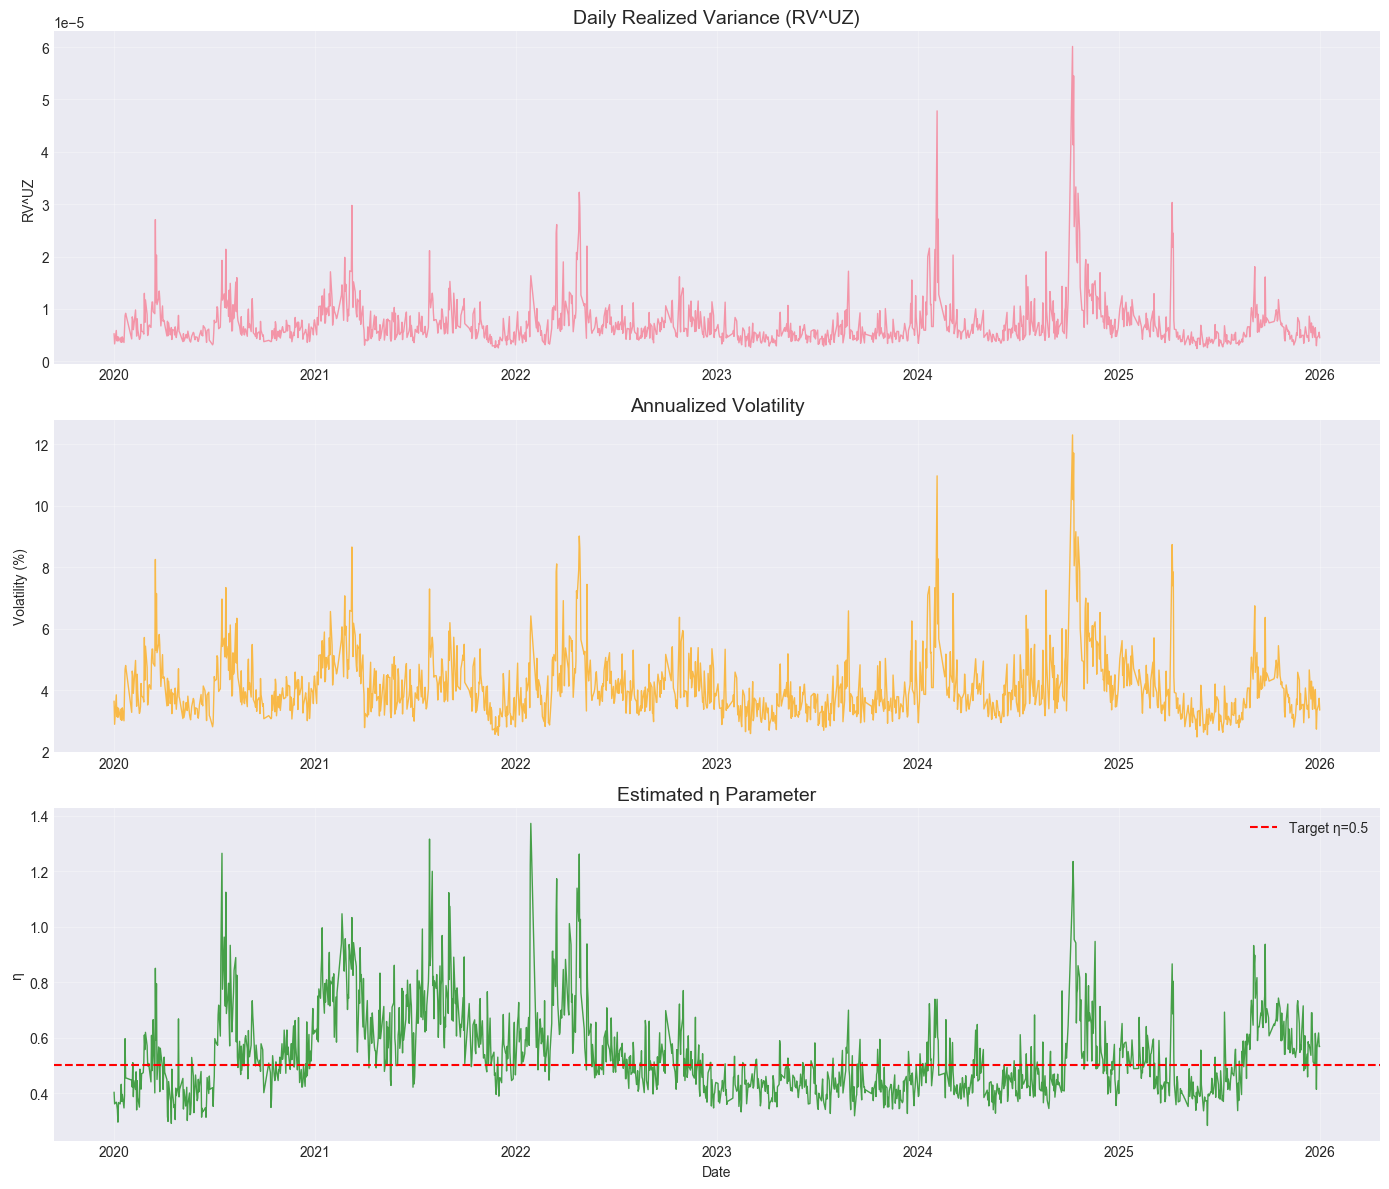

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(df_variance.index, df_variance['rv_uz'], linewidth=1, alpha=0.7)
axes[0].set_title('Daily Realized Variance (RV^UZ)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RV^UZ')
axes[0].grid(True, alpha=0.3)

df_variance['annualized_vol'] = np.sqrt(df_variance['rv_uz'] * 252) * 100
axes[1].plot(df_variance.index, df_variance['annualized_vol'], 
             linewidth=1, alpha=0.7, color='orange')
axes[1].set_title('Annualized Volatility', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volatility (%)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_variance.index, df_variance['eta'], linewidth=1, alpha=0.7, color='green')
axes[2].axhline(y=0.5, color='r', linestyle='--', label='Target η=0.5')
axes[2].set_title('Estimated η Parameter', fontsize=14, fontweight='bold')
axes[2].set_ylabel('η')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
print("="*60)
print("Statistical Summary")
print("="*60)
print(f"\nSample size: {len(df_variance)} trading days")
print(f"Date range: {df_variance.index[0].date()} to {df_variance.index[-1].date()}")

print(f"\n[RV^UZ Stats]")
print(f"  Mean: {df_variance['rv_uz'].mean():.6f}")
print(f"  Std: {df_variance['rv_uz'].std():.6f}")
print(f"  Median: {df_variance['rv_uz'].median():.6f}")
print(f"  Min: {df_variance['rv_uz'].min():.6f}")
print(f"  Max: {df_variance['rv_uz'].max():.6f}")

print(f"\n[Annualized Vol Stats]")
print(f"  Mean: {df_variance['annualized_vol'].mean():.2f}%")
print(f"  Std: {df_variance['annualized_vol'].std():.2f}%")
print(f"  Min: {df_variance['annualized_vol'].min():.2f}%")
print(f"  Max: {df_variance['annualized_vol'].max():.2f}%")

print(f"\n[η Parameter Stats]")
print(f"  Mean: {df_variance['eta'].mean():.4f}")
print(f"  Std: {df_variance['eta'].std():.4f}")
print(f"  Avg deviation from 0.5: {abs(df_variance['eta'] - 0.5).mean():.4f}")

print(f"\n[Tick Size Stats]")
print(f"  Mean: {df_variance['tick_size'].mean():.6f}")
print(f"  Unique values: {df_variance['tick_size'].nunique()}")
if df_variance['tick_size'].nunique() == 1:
    print(f"  Fixed tick_size: {df_variance['tick_size'].iloc[0]:.6f}")

Statistical Summary

Sample size: 1455 trading days
Date range: 2020-01-02 to 2025-12-31

[RV^UZ Stats]
  Mean: 0.000007
  Std: 0.000004
  Median: 0.000006
  Min: 0.000002
  Max: 0.000060

[Annualized Vol Stats]
  Mean: 4.11%
  Std: 1.04%
  Min: 2.48%
  Max: 12.31%

[η Parameter Stats]
  Mean: 0.5389
  Std: 0.1548
  Avg deviation from 0.5: 0.1139

[Tick Size Stats]
  Mean: 0.020000
  Unique values: 1
  Fixed tick_size: 0.020000


# 5. Save Results

Save results to CSV for subsequent analysis

In [8]:
import os

output_dir = '../data'
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, f'variance_proxy_{start_date}_{end_date}.csv')
df_variance.to_csv(output_file)

print(f"Data saved to: {output_file}")
print(f"  File size: {os.path.getsize(output_file) / 1024:.2f} KB")

Data saved to: ../data/variance_proxy_20200101_20251231.csv
  File size: 113.44 KB


# 6. Hurst Exponent and Roughness Analysis

H = 0.106, is_rough: True


<Axes: title={'center': 'Hurst Estimation (Variogram)\nH = 0.106, R² = 0.931'}, xlabel='log(lag τ)', ylabel='log(E[|Δ|^2.0])'>

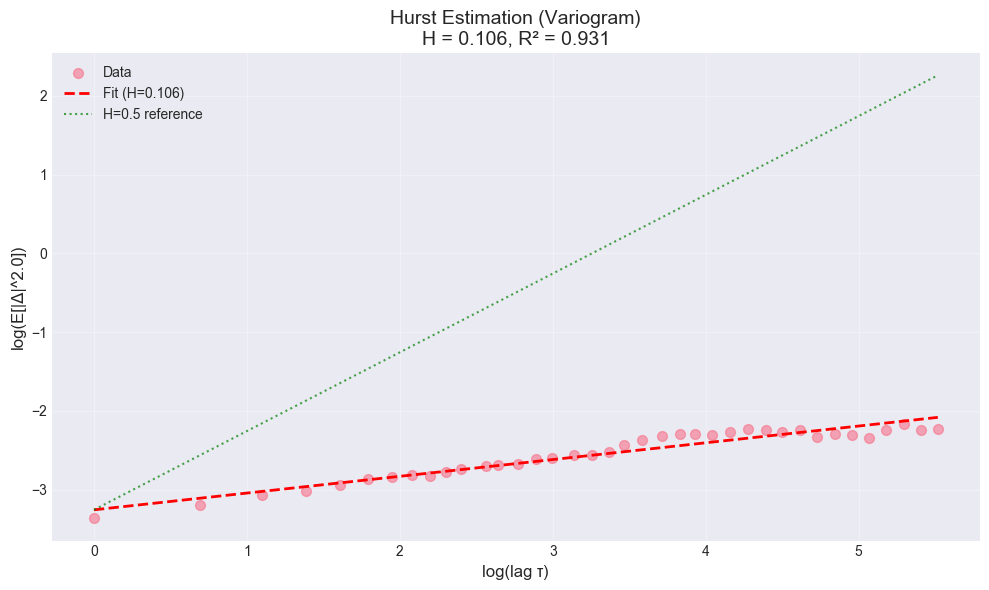

In [9]:
from HurstEstimator import HurstEstimator

hurst = HurstEstimator()

log_volatility_series = np.log(np.sqrt(df_variance['rv_uz']))

# Basic estimation
H, info = hurst.estimate_hurst_variogram(log_volatility_series, q=2.0)

# Multi-scale robust estimation
H_mean, summary = hurst.estimate_hurst_multiscale(log_volatility_series)

# Rough volatility test
test_result = hurst.estimate_hurst_roughness_test(log_volatility_series)
print(f"H = {test_result['H']:.3f}, is_rough: {test_result['is_rough']}")

# Visualization
hurst.plot_variogram(log_volatility_series, q=2.0)

Multi-scale Hurst Estimation - Overlay Visualization

Hurst estimates by q:
  q=0.5: H = 0.1106, R² = 0.9211
  q=1.0: H = 0.1095, R² = 0.9263
  q=1.5: H = 0.1081, R² = 0.9289
  q=2.0: H = 0.1064, R² = 0.9308
  q=2.5: H = 0.1044, R² = 0.9322
  q=3.0: H = 0.1021, R² = 0.9332

Mean Hurst: 0.1069 ± 0.0029
Volatility exhibits roughness (H < 0.5)


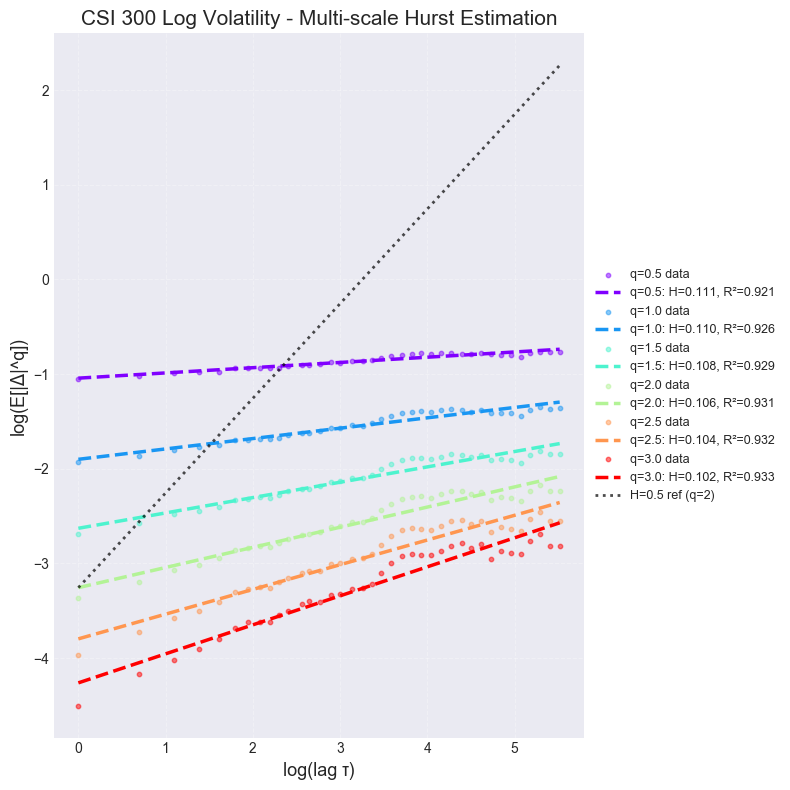

In [10]:
# Demo: plot multiple q regression lines on one figure
from HurstEstimator import HurstEstimator

hurst = HurstEstimator()

# Use log volatility
log_volatility_series = np.log(np.sqrt(df_variance['rv_uz']))

print("=" * 60)
print("Multi-scale Hurst Estimation - Overlay Visualization")
print("=" * 60)

# Define q values to plot
q_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

# Plot variograms and regression lines for all q on one figure
fig, ax, results = hurst.plot_multiscale_overlay(
    log_volatility_series,
    q_values=q_values,
    figsize=(8, 8),
    show_reference=True,
    title='CSI 300 Log Volatility - Multi-scale Hurst Estimation'
)

# Print estimation results for each q
print("\nHurst estimates by q:")
for q in q_values:
    if q in results:
        H = results[q]['H']
        r2 = results[q]['info']['r_squared']
        print(f"  q={q}: H = {H:.4f}, R² = {r2:.4f}")

# Compute mean and std
H_values = [results[q]['H'] for q in q_values if q in results]
if H_values:
    H_mean = np.mean(H_values)
    H_std = np.std(H_values)
    print(f"\nMean Hurst: {H_mean:.4f} ± {H_std:.4f}")
    
    # Rough volatility check
    if H_mean < 0.5:
        print(f"Volatility exhibits roughness (H < 0.5)")
    else:
        print(f"Volatility does not exhibit roughness (H >= 0.5)")

plt.show()